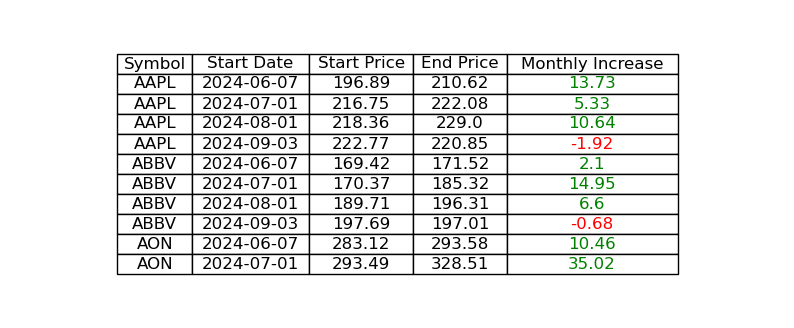

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# Sample DataFrame
data = {
    'symbol': ['AAPL', 'AAPL', 'AAPL', 'AAPL', 'ABBV', 'ABBV', 'ABBV', 'ABBV', 'AON', 'AON'],
    'month_start_date': ['2024-06-07', '2024-07-01', '2024-08-01', '2024-09-03', 
                         '2024-06-07', '2024-07-01', '2024-08-01', '2024-09-03', 
                         '2024-06-07', '2024-07-01'],
    'month_start_price': [196.89, 216.75, 218.36, 222.77, 169.42, 170.37, 189.71, 197.69, 283.12, 293.49],
    'month_end_price': [210.62, 222.08, 229.00, 220.85, 171.52, 185.32, 196.31, 197.01, 293.58, 328.51],
    'monthly_increase': [13.73, 5.33, 10.64, -1.92, 2.10, 14.95, 6.60, -0.68, 10.46, 35.02]
}
df = pd.DataFrame(data)

# Define table data (rows of lists)
table_data = []
for i, row in df.iterrows():
    table_data.append([row['symbol'], row['month_start_date'], row['month_start_price'], 
                       row['month_end_price'], row['monthly_increase']])

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 4))

# Hide axes (we only want to show the table)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Create table
table = ax.table(cellText=table_data, colLabels=['Symbol', 'Start Date', 'Start Price', 
                                                 'End Price', 'Monthly Increase'], 
                 cellLoc='center', loc='center')

# Adjust table style
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Color the Monthly Increase column (positive green, negative red)
for i in range(1, len(table_data) + 1):  # Skip the header row
    increase = table_data[i-1][4]
    color = 'green' if increase > 0 else 'red'
    table[(i, 4)].set_text_props(color=color)  # Monthly Increase column is index 4

# Set column widths
table.auto_set_column_width([0, 1, 2, 3, 4])

# Display the plot (table)
plt.show()


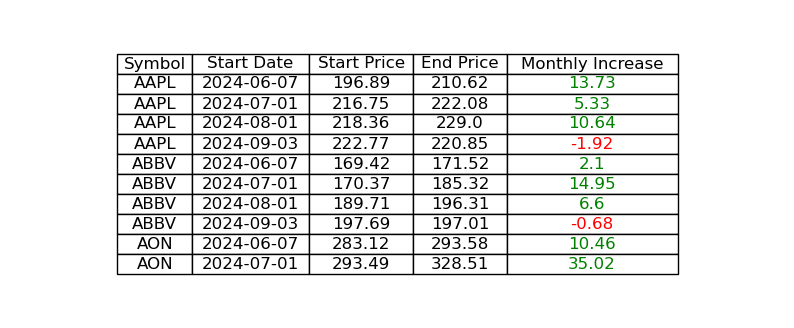

Dropdown(description='Symbol:', options=('All', 'AAPL', 'ABBV', 'AON'), value='All')

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# Sample DataFrame setup
data = {
    'symbol': ['AAPL', 'AAPL', 'AAPL', 'AAPL', 'ABBV', 'ABBV', 'ABBV', 'ABBV', 'AON', 'AON'],
    'month_start_date': ['2024-06-07', '2024-07-01', '2024-08-01', '2024-09-03', 
                         '2024-06-07', '2024-07-01', '2024-08-01', '2024-09-03', 
                         '2024-06-07', '2024-07-01'],
    'month_start_price': [196.89, 216.75, 218.36, 222.77, 169.42, 170.37, 189.71, 197.69, 283.12, 293.49],
    'month_end_price': [210.62, 222.08, 229.00, 220.85, 171.52, 185.32, 196.31, 197.01, 293.58, 328.51],
    'monthly_increase': [13.73, 5.33, 10.64, -1.92, 2.10, 14.95, 6.60, -0.68, 10.46, 35.02]
}
df = pd.DataFrame(data)

# Create a dropdown widget for symbol selection
symbols = ['All'] + list(df['symbol'].unique())
symbol_dropdown = widgets.Dropdown(options=symbols, description='Symbol:')

# Function to update the table
def update_table(selected_symbol):
    # Clear previous output to avoid multiple tables being shown
    clear_output(wait=True)
    
    # Filter data based on selected symbol
    if selected_symbol != 'All':
        filtered_df = df[df['symbol'] == selected_symbol]
    else:
        filtered_df = df

    # Define table data
    table_data = []
    for i, row in filtered_df.iterrows():
        table_data.append([row['symbol'], row['month_start_date'], row['month_start_price'], 
                           row['month_end_price'], row['monthly_increase']])

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 4))

    # Hide axes (we only want to show the table)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_frame_on(False)

    # Create table
    table = ax.table(cellText=table_data, colLabels=['Symbol', 'Start Date', 'Start Price', 
                                                     'End Price', 'Monthly Increase'], 
                     cellLoc='center', loc='center')

    # Adjust table style
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.2)

    # Color the Monthly Increase column (positive green, negative red)
    for i in range(1, len(table_data) + 1):  # Skip the header row
        increase = table_data[i-1][4]
        color = 'green' if increase > 0 else 'red'
        table[(i, 4)].set_text_props(color=color)

    # Set column widths
    table.auto_set_column_width([0, 1, 2, 3, 4])

    # Display the plot (table)
    plt.show()

    # Redisplay the dropdown
    display(symbol_dropdown)

# Observe the symbol selection and update the table when it changes
def on_symbol_change(change):
    update_table(change['new'])

# Attach the function to the dropdown's change event
symbol_dropdown.observe(on_symbol_change, names='value')

# Display the dropdown to initiate the table
display(symbol_dropdown)

# Initial display for 'All'
update_table('All')
